In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [4]:
app = pd.read_csv('/content/application_train (2)_predictive.csv')
bureau = pd.read_csv('/content/bureau_predictive.csv')

In [5]:
print(app.head())

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...               0.0             

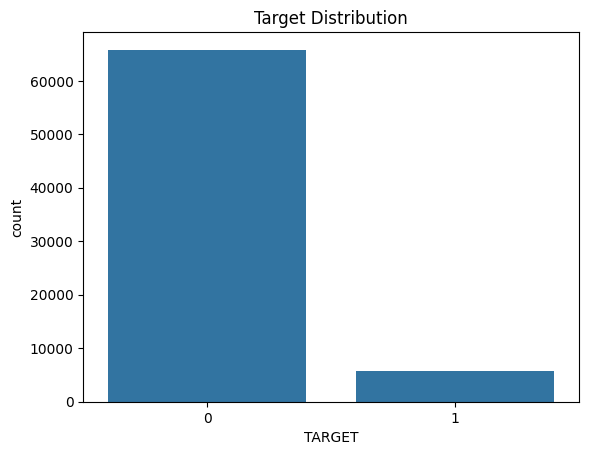

TARGET
0    0.91969
1    0.08031
Name: proportion, dtype: float64


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='TARGET', data=app)
plt.title("Target Distribution")
plt.show()

print(app['TARGET'].value_counts(normalize=True))

In [7]:
corr = app.corr(numeric_only=True)['TARGET'].sort_values(ascending=False)
print(corr.head(10))
print("*"*50)
print(corr.tail(10))

TARGET                         1.000000
DAYS_BIRTH                     0.079090
REGION_RATING_CLIENT           0.063085
REGION_RATING_CLIENT_W_CITY    0.062557
DAYS_LAST_PHONE_CHANGE         0.055855
DAYS_ID_PUBLISH                0.051435
REG_CITY_NOT_WORK_CITY         0.046760
FLAG_DOCUMENT_3                0.044741
FLAG_EMP_PHONE                 0.042764
DAYS_REGISTRATION              0.042732
Name: TARGET, dtype: float64
**************************************************
ELEVATORS_AVG                -0.034784
REGION_POPULATION_RELATIVE   -0.040269
FLOORSMAX_MODE               -0.040448
AMT_GOODS_PRICE              -0.040754
FLOORSMAX_MEDI               -0.041030
FLOORSMAX_AVG                -0.041623
DAYS_EMPLOYED                -0.041663
EXT_SOURCE_1                 -0.154263
EXT_SOURCE_2                 -0.160350
EXT_SOURCE_3                 -0.177366
Name: TARGET, dtype: float64


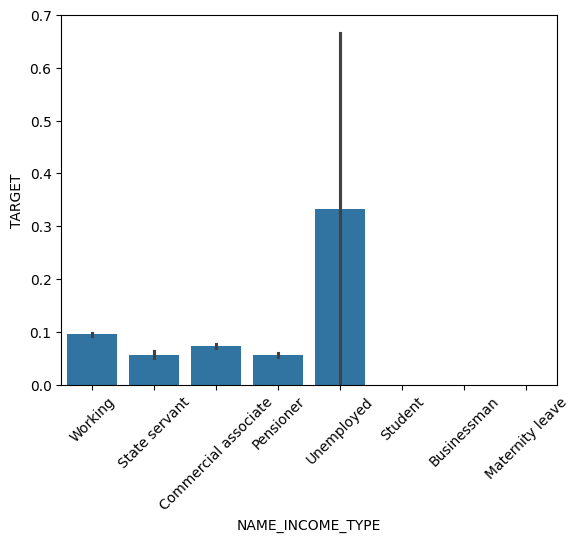

In [8]:
sns.barplot(x='NAME_INCOME_TYPE', y='TARGET', data=app)
plt.xticks(rotation=45)
plt.show()

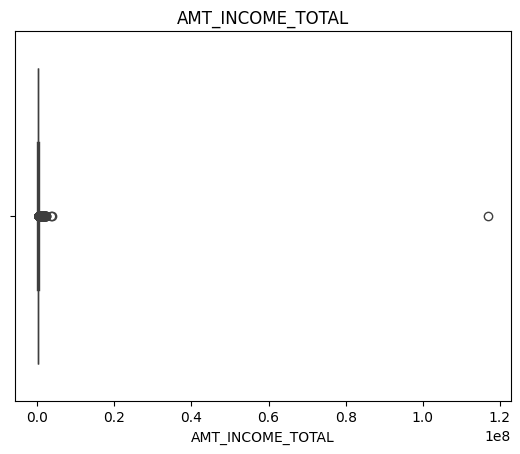

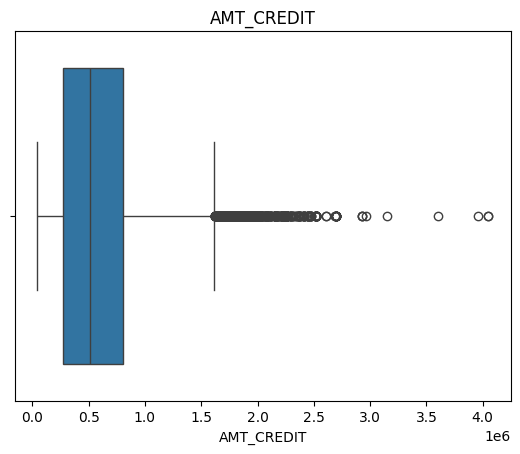

In [9]:
for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT']:
    sns.boxplot(x=app[col])
    plt.title(col)
    plt.show()

In [10]:
# Ratios (IMPORTANT)
app['credit_income_ratio'] = app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL']
app['annuity_income_ratio'] = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL']
app['credit_goods_ratio'] = app['AMT_CREDIT'] / app['AMT_GOODS_PRICE']
app['income_per_person'] = app['AMT_INCOME_TOTAL'] / app['CNT_FAM_MEMBERS']

# Replace inf
app.replace([np.inf, -np.inf], np.nan, inplace=True)

In [11]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_SUM': ['mean', 'sum'],
    'AMT_CREDIT_SUM_DEBT': ['mean', 'sum'],
    'CREDIT_ACTIVE': 'count'
})

bureau_agg.columns = ['_'.join(col) for col in bureau_agg.columns]
bureau_agg.reset_index(inplace=True)

# Merge with application data
df = app.merge(bureau_agg, on='SK_ID_CURR', how='left')

In [12]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

In [13]:
df.fillna(0, inplace=True)

X = df.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Training the model

In [14]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)
log_reg.fit(X_train, y_train)

y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
# rf = RandomForestClassifier(
#     n_estimators=300,
#     max_depth=None,
#     class_weight='balanced_subsample',
#     n_jobs=-1,
#     random_state=42
# )

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced_subsample'
)

rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [16]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

lgbm.fit(X_train, y_train)

y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

[LightGBM] [Info] Number of positive: 4598, number of negative: 52650
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.070385 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12856
[LightGBM] [Info] Number of data points in the train set: 57248, number of used features: 121
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080317 -> initscore=-2.438045
[LightGBM] [Info] Start training from score -2.438045
